
Merged preview:
  Animal Treatment  PI_ROI_anymaze  PI_WC_anymaze  PI_ROI_boris  PI_WC_boris
0  2_3_1  cagemate        0.537092       0.037425      0.853307    -0.065368
1  1_4_1    lowfam        0.030216      -0.043902      0.194519    -0.068128
2  2_2_1  cagemate        0.790429      -0.737509      0.837923     0.763785
3  1_2_1    lowfam       -0.537152       0.509903      1.000000    -0.489893
4  1_1_1    lowfam       -0.859519       0.806573     -0.790507    -0.817411

ROI correlation: r=0.753, p=0.0008
WC correlation: r=-0.063, p=0.8159

Flips (ROI):
   Animal Treatment dir_anymaze dir_boris
3   1_2_1    lowfam       novel    social
11  2_1_1    lowfam      social     novel


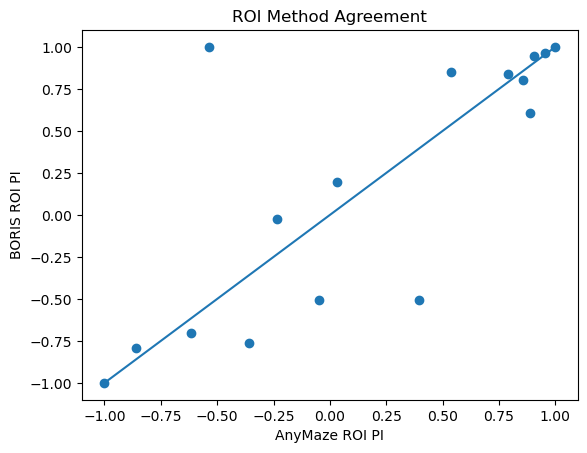

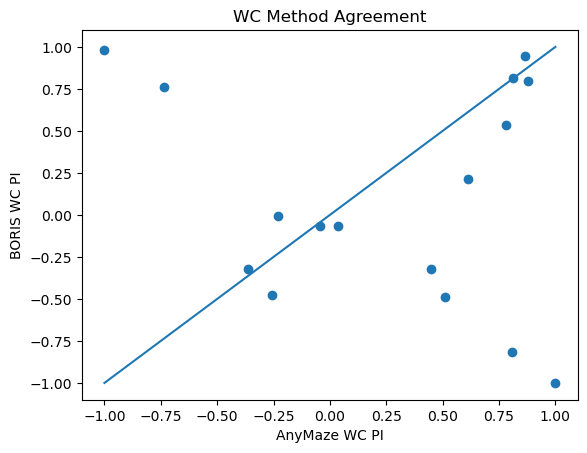

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

file_path = r"D:\Simmone_MOE_df\cohort_1_sm_anymaze_boris_post_MOE.xlsx"

# ======================
# LOAD DATA
# ======================

anymaze = pd.read_excel(file_path, sheet_name="anymaze_data")
boris   = pd.read_excel(file_path, sheet_name="boris_data")

# ======================
# CLEAN DATA
# ======================

anymaze["Animal"] = anymaze["Animal"].astype(str).str.replace(".", "_", regex=False)
boris["Animal"]   = boris["Animal"].astype(str)

anymaze["Treatment"] = anymaze["Treatment"].str.lower().str.replace(" ", "")
boris["Treatment"]   = boris["Treatment"].str.lower().str.replace(" ", "")

# ======================
# PREFERENCE INDEX FUNCTION
# ======================

def compute_pi(social, novel):
    return (social - novel) / (social + novel + 1e-6)

# ======================
# ROI PREFERENCE
# ======================

anymaze["PI_ROI"] = compute_pi(
    anymaze["Agent ROI : time investigating"],
    anymaze["Novel ROI : time investigating"]
)

boris["PI_ROI"] = compute_pi(
    boris["Social ROI"],
    boris["Novel ROI"]
)

# ======================
# WHOLE CHAMBER PREFERENCE
# ======================

anymaze["PI_WC"] = compute_pi(
    anymaze["Whole Chamber agent : time"],
    anymaze["Whole Chamber novel : time"]
)

boris["PI_WC"] = compute_pi(
    boris["Social WC"],
    boris["Novel WC"]
)

# ======================
# MERGE DATA
# ======================

merged = pd.merge(
    anymaze[["Animal","Treatment","PI_ROI","PI_WC"]],
    boris[["Animal","Treatment","PI_ROI","PI_WC"]],
    on=["Animal","Treatment"],
    suffixes=("_anymaze","_boris")
)

print("\nMerged preview:")
print(merged.head())

# ======================
# CORRELATION (ROI)
# ======================

r_roi, p_roi = spearmanr(merged["PI_ROI_anymaze"], merged["PI_ROI_boris"])
print(f"\nROI correlation: r={r_roi:.3f}, p={p_roi:.4f}")

# ======================
# CORRELATION (WC)
# ======================

r_wc, p_wc = spearmanr(merged["PI_WC_anymaze"], merged["PI_WC_boris"])
print(f"WC correlation: r={r_wc:.3f}, p={p_wc:.4f}")

# ======================
# DETECT FLIPS
# ======================

def direction(x):
    if x > 0:
        return "social"
    elif x < 0:
        return "novel"
    else:
        return "neutral"

merged["dir_anymaze"] = merged["PI_ROI_anymaze"].apply(direction)
merged["dir_boris"]   = merged["PI_ROI_boris"].apply(direction)

flips = merged[merged["dir_anymaze"] != merged["dir_boris"]]

print("\nFlips (ROI):")
print(flips[["Animal","Treatment","dir_anymaze","dir_boris"]])

# ======================
# PLOT — ROI CORRELATION
# ======================

plt.figure()
plt.scatter(merged["PI_ROI_anymaze"], merged["PI_ROI_boris"])

lims = [
    min(merged["PI_ROI_anymaze"].min(), merged["PI_ROI_boris"].min()),
    max(merged["PI_ROI_anymaze"].max(), merged["PI_ROI_boris"].max())
]

plt.plot(lims, lims)

plt.xlabel("AnyMaze ROI PI")
plt.ylabel("BORIS ROI PI")
plt.title("ROI Method Agreement")
plt.show()

# ======================
# PLOT — WC CORRELATION
# ======================

plt.figure()
plt.scatter(merged["PI_WC_anymaze"], merged["PI_WC_boris"])

lims = [
    min(merged["PI_WC_anymaze"].min(), merged["PI_WC_boris"].min()),
    max(merged["PI_WC_anymaze"].max(), merged["PI_WC_boris"].max())
]

plt.plot(lims, lims)

plt.xlabel("AnyMaze WC PI")
plt.ylabel("BORIS WC PI")
plt.title("WC Method Agreement")
plt.show()

In [5]:
def compute_di(novel, social, total):
    return (novel - social) / (total + 1e-6)

# ======================
# ANYMAZE DI
# ======================

anymaze["DI"] = compute_di(
    anymaze["Novel ROI : time investigating"],
    anymaze["Agent ROI : time investigating"],
    anymaze["Whole-Chamber : time"]
)

# ======================
# BORIS DI
# ======================

boris["DI"] = compute_di(
    boris["Novel ROI"],
    boris["Social ROI"],
    boris["Whole"]
)

In [6]:
merged = pd.merge(
    anymaze[["Animal","Treatment","DI"]],
    boris[["Animal","Treatment","DI"]],
    on=["Animal","Treatment"],
    suffixes=("_anymaze","_boris")
)

DI correlation: r=0.776, p=0.0004


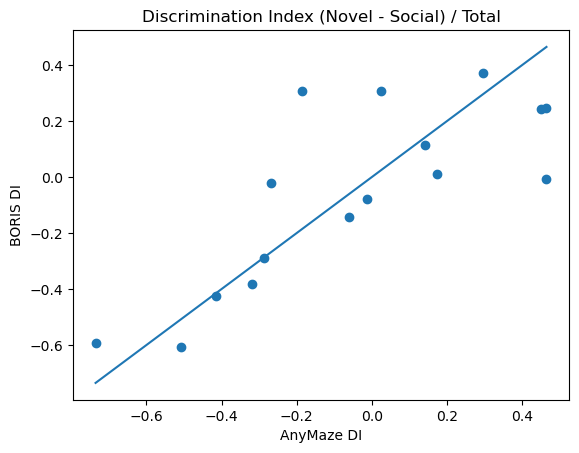

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr

x = merged["DI_anymaze"]
y = merged["DI_boris"]

# stats
r, p = spearmanr(x, y)
print(f"DI correlation: r={r:.3f}, p={p:.4f}")

plt.figure()
plt.scatter(x, y)

# identity line
lims = [min(x.min(), y.min()), max(x.max(), y.max())]
plt.plot(lims, lims)

plt.xlabel("AnyMaze DI")
plt.ylabel("BORIS DI")
plt.title("Discrimination Index (Novel - Social) / Total")

plt.show()

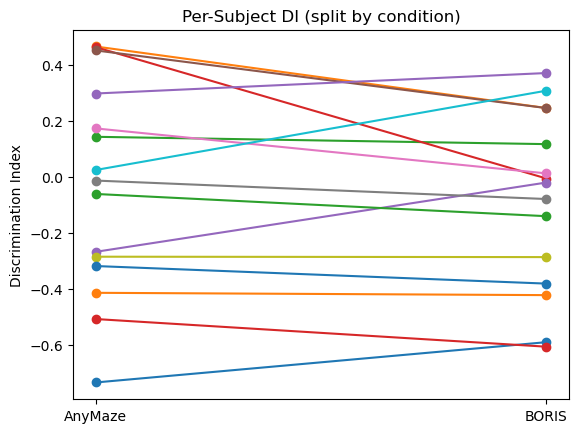

In [9]:
plt.figure()

for (animal, condition), sub in merged.groupby(["Animal","Treatment"]):
    plt.plot(
        ["AnyMaze","BORIS"],
        [sub["DI_anymaze"].values[0], sub["DI_boris"].values[0]],
        marker='o'
    )

plt.ylabel("Discrimination Index")
plt.title("Per-Subject DI (split by condition)")
plt.show()

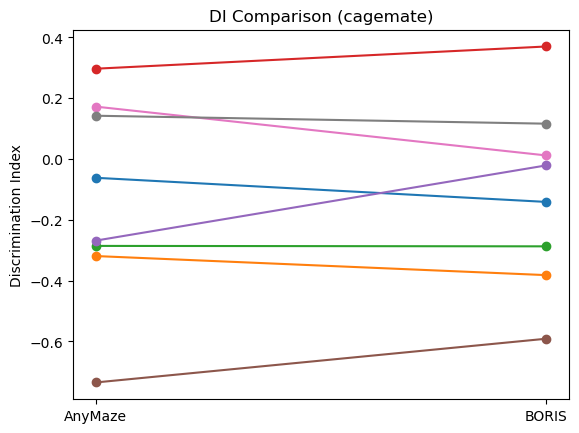

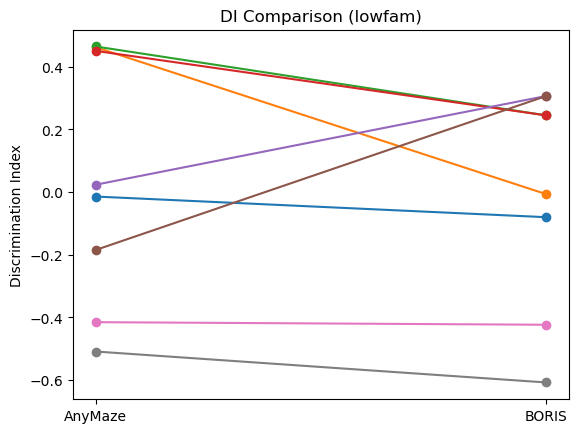

In [10]:
for condition in merged["Treatment"].unique():
    plt.figure()
    sub_df = merged[merged["Treatment"] == condition]
    
    for _, row in sub_df.iterrows():
        plt.plot(
            ["AnyMaze","BORIS"],
            [row["DI_anymaze"], row["DI_boris"]],
            marker='o'
        )
    
    plt.title(f"DI Comparison ({condition})")
    plt.ylabel("Discrimination Index")
    plt.show()